In [5]:
!ls -lrt logs/sensor_data_*.log | tail | awk '{ if ($5 != 0) { print $0} }'

-rw-r--r-- 1 pi pi    2087 Jul 30 16:44 logs/sensor_data_20250730-204331.log
-rw-r--r-- 1 pi pi   50900 Jul 30 17:03 logs/sensor_data_20250730-204423.log
-rw-r--r-- 1 pi pi 3515523 Jul 31 22:25 logs/sensor_data_20250730-210455.log
-rw-r--r-- 1 pi pi  897283 Aug 11 05:44 logs/sensor_data_20250809-200024.log
-rw-r--r-- 1 pi pi   91380 Aug 11 11:32 logs/sensor_data_20250811-145756.log


In [7]:
# Parse all JSONL sensor logs into a single time series DataFrame with UTC timestamp index
import json
from pathlib import Path
import pandas as pd

# Discover all matching log files
log_dir = Path("logs")
#files = sorted(log_dir.glob("sensor_data_*.log"))
files = sorted(log_dir.glob("sensor_data_20250811-145756.log"))
if not files:
    print("No sensor_data_*.log files found in logs/.")

rows = []
files_processed = 0
files_skipped_empty = 0

for fp in files:
    # Skip empty files quickly
    try:
        if fp.stat().st_size == 0:
            files_skipped_empty += 1
            continue
    except Exception:
        # If stat fails, attempt to open anyway
        pass

    start_count = len(rows)
    try:
        with fp.open("r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    # Skip malformed lines
                    continue

                # Timestamp handling
                ts = rec.get("timestamp")
                try:
                    ts_val = float(ts) if ts is not None else None
                except (TypeError, ValueError):
                    ts_val = None

                row = {}
                if ts_val is not None:
                    # Use UTC to avoid timezone ambiguity; adjust as needed
                    row["timestamp"] = pd.to_datetime(ts_val, unit="s", utc=True)

                # Flatten sensor data with sensor prefix (e.g., vedirect_V, gps_latitude, ...)
                sensors = rec.get("sensors", {}) or {}
                sensor_added = False
                for s_name, s_vals in sensors.items():
                    if isinstance(s_vals, dict):
                        for k, v in s_vals.items():
                            row[f"{s_name}_{k}"] = v
                            sensor_added = True
                    else:
                        row[s_name] = s_vals
                        sensor_added = True

                # Exclude rows with no data (i.e., no sensor fields parsed)
                if sensor_added:
                    rows.append(row)
    except FileNotFoundError:
        continue

    if len(rows) > start_count:
        files_processed += 1
    else:
        # File had content but contributed no valid rows
        files_skipped_empty += 1

# Build DataFrame, set index, drop duplicate timestamps, and attempt numeric conversion
_df = pd.DataFrame(rows)
if not _df.empty and "timestamp" in _df.columns:
    _df = _df.set_index("timestamp").sort_index()
    # If multiple rows share the same timestamp, keep the last observed
    _df = _df[~_df.index.duplicated(keep="last")]

# Convert columns to numeric where possible without using deprecated errors="ignore"
for col in _df.columns:
    try:
        _df[col] = pd.to_numeric(_df[col])
    except Exception:
        # Leave column unchanged if it cannot be fully converted to numeric
        pass

# Insert NaN marker rows for calendar days with no data to force plot discontinuities
if not _df.empty and isinstance(_df.index, pd.DatetimeIndex):
    if _df.index.tz is None:
        # Assume UTC if tz-naive
        _df = _df.tz_localize("UTC")
    # Build complete daily range between first and last day
    start_day = _df.index.min().normalize()
    end_day = _df.index.max().normalize()
    all_days = pd.date_range(start_day, end_day, freq="D", tz=_df.index.tz)
    present_days = _df.index.normalize().unique()
    missing_days = all_days.difference(present_days)
    if len(missing_days) > 0:
        # Place markers at 12:00 UTC within each missing day
        missing_ts = missing_days + pd.Timedelta(hours=12)
        # Reindex with union to create all-NaN rows at missing timestamps without dtype warnings
        _df = _df.reindex(_df.index.union(missing_ts)).sort_index()

# Final DataFrame
df = _df
print(f"Files found: {len(files)}, processed: {files_processed}, skipped_empty_or_nodata: {files_skipped_empty}")
print(f"DataFrame shape: {df.shape}")
df.head()

Files found: 1, processed: 1, skipped_empty_or_nodata: 0
DataFrame shape: (132, 34)


,vedirect_V,vedirect_I,vedirect_VPV,vedirect_PPV,vedirect_IL,vedirect_CS,vedirect_MPPT,vedirect_ERR,vedirect_H19,vedirect_H20,...,bno08x_ay,bno08x_az,bno08x_gx,bno08x_gy,bno08x_gz,bno08x_mx,bno08x_my,bno08x_mz,htu31d_temperature,htu31d_relative_humidity
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-08-11 14:57:58.654999971+00:00,12970,-600,10,0,600,0,0,0,287,0,...,5.800781,2.496094,0.003906,0.001953,0.0,-115.0625,53.6875,-20.3125,23.638361,60.302129
2025-08-11 14:58:14.657999992+00:00,12970,-540,10,0,500,0,0,0,287,0,...,5.761719,2.496094,0.000000,0.000000,0.0,-113.0625,52.8125,-17.3125,23.618219,60.318914
2025-08-11 14:58:30.634999990+00:00,12970,-560,10,0,500,0,0,0,287,0,...,5.800781,2.496094,0.000000,0.000000,0.0,-115.2500,53.9375,-20.5625,23.678645,60.285344
2025-08-11 14:58:46.648000002+00:00,12940,-980,10,0,900,0,0,0,287,0,...,5.761719,2.496094,0.003906,0.001953,0.0,-115.3750,53.4375,-18.4375,23.557794,60.320439
2025-08-11 14:59:02.611999989+00:00,12960,-600,10,0,600,0,0,0,287,0,...,5.800781,2.496094,0.000000,0.000000,0.0,-112.5000,52.7500,-17.5000,23.618219,60.291447


Text(0, 0.5, 'voltage (V)')

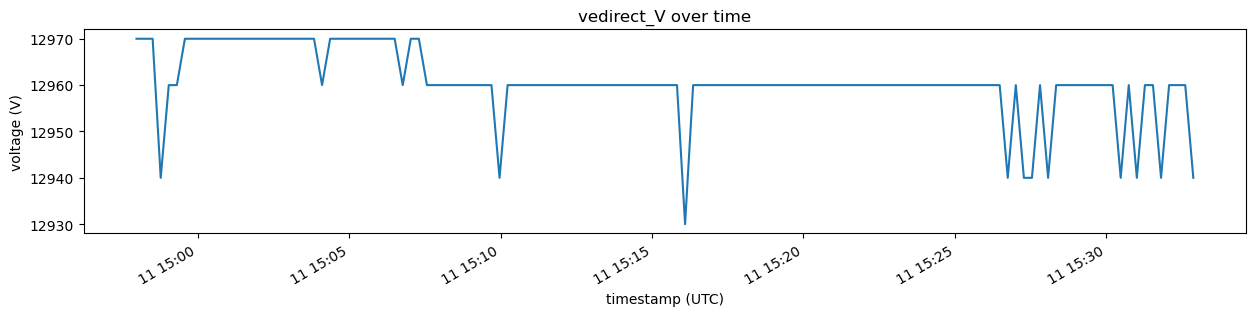

In [8]:
# Robust plotting for vedirect voltage column
import pandas as pd

# Ensure df exists and is populated
try:
    df
except NameError as e:
    raise RuntimeError("DataFrame 'df' is not defined. Run the previous cell to build it.") from e

if df.empty:
    raise ValueError("DataFrame 'df' is empty. Check the log path and parsing in the previous cell.")

# Pick the target column
target_col = None
if "vedirect_V" in df.columns:
    target_col = "vedirect_V"
else:
    # Try to find a likely vedirect voltage column
    lc = [c for c in df.columns]
    candidates = [
        c for c in lc
        if ("vedirect" in c.lower()) and (c.lower().endswith("_v") or c.lower() == "vedirect_v")
    ]
    if candidates:
        target_col = candidates[0]

if not target_col:
    raise KeyError(
        "Could not find 'vedirect_V' in DataFrame columns. Available columns: "
        + ", ".join(sorted(map(str, df.columns)))
    )

# Convert to numeric; KEEP NaNs to enforce gaps on plots
try:
    s_num = pd.to_numeric(df[target_col], errors="coerce")
except Exception:
    s_num = pd.to_numeric(df[target_col], errors="coerce")

# If all values are NaN, nothing to plot
if not s_num.notna().any():
    raise ValueError(f"Column '{target_col}' has no numeric values to plot.")

ax = s_num.plot(figsize=(15, 3), title=f"{target_col} over time")
ax.set_xlabel("timestamp (UTC)")
ax.set_ylabel("voltage (V)")

In [9]:
# Derive useful columns and classify day/night
import numpy as np
import pandas as pd

# Ensure we have a datetime index (UTC)
if not isinstance(df.index, pd.DatetimeIndex):
    raise TypeError("df must have a DatetimeIndex. Re-run the parsing cell.")
if df.index.tz is None:
    # Assume UTC if tz-naive
    df = df.tz_localize("UTC")

def pick_col(frame, *names):
    for c in frame.columns:
        lc = c.lower()
        for n in names:
            if lc == n.lower():
                return c
    return None

v_batt = pick_col(df, "vedirect_v", "battery_v", "v")
i_batt = pick_col(df, "vedirect_i", "battery_i", "i")
p_pv   = pick_col(df, "vedirect_ppv", "ppv", "pv_power")
v_pv   = pick_col(df, "vedirect_vpv", "vpv", "pv_voltage")

if v_batt is None:
    raise KeyError("Couldn't find a battery voltage column (e.g., 'vedirect_V').")

# Compute battery power (W) if possible
if i_batt is not None:
    with np.errstate(all="ignore"):
        df["derived_P_batt_W"] = pd.to_numeric(df[v_batt], errors="coerce") * pd.to_numeric(df[i_batt], errors="coerce")

# Classify daylight
is_daylight = None
if p_pv is not None:
    is_daylight = (pd.to_numeric(df[p_pv], errors="coerce").fillna(0) > 1.0)
elif v_pv is not None:
    vb = pd.to_numeric(df[v_batt], errors="coerce")
    vp = pd.to_numeric(df[v_pv], errors="coerce")
    is_daylight = (vp > (vb + 1.0))
else:
    # Fallback heuristic by hour (UTC). Adjust if needed.
    hrs = df.index.tz_convert("UTC").hour
    is_daylight = (hrs >= 8) & (hrs <= 17)

df["derived_is_daylight"] = is_daylight.astype(bool)
df["derived_hour_utc"] = df.index.tz_convert("UTC").hour
print({
    "v_batt": v_batt,
    "i_batt": i_batt,
    "p_pv": p_pv,
    "v_pv": v_pv,
    "daylight_detected_with": ("p_pv" if p_pv else ("v_pv" if v_pv else "hour_heuristic"))
})

{'v_batt': 'vedirect_V', 'i_batt': 'vedirect_I', 'p_pv': 'vedirect_PPV', 'v_pv': 'vedirect_VPV', 'daylight_detected_with': 'p_pv'}


In [10]:
# Detect rapid voltage deterioration window and daily aggregates
import numpy as np
import pandas as pd

vb = pd.to_numeric(df[v_batt], errors="coerce")
# Use a rolling min slope to detect steep drops
# Compute first difference per second (approx) using index deltas
dt_sec = df.index.to_series().diff().dt.total_seconds().fillna(0).replace(0, np.nan)
dv = vb.diff()
slope_v_per_s = dv / dt_sec
# Smooth slope to reduce noise
slope_sm = slope_v_per_s.rolling(5, min_periods=1, center=True).median()
df["derived_dVdt_V_per_s"] = slope_sm

# Heuristic thresholds: drop faster than -0.005 V/s (~0.3 V/min)
crash_mask = slope_sm < -0.005
crash_ranges = []
in_range = False
start = None
for t, is_crash in crash_mask.items():
    if is_crash and not in_range:
        in_range = True
        start = t
    elif not is_crash and in_range:
        crash_ranges.append((start, t))
        in_range = False
if in_range and start is not None:
    crash_ranges.append((start, df.index[-1]))

crash_ranges = [(s, e) for (s, e) in crash_ranges if (e - s).total_seconds() > 60]  # keep >1 min
print({"crash_windows": crash_ranges[:3], "count": len(crash_ranges)})

# Daily aggregates
df_day = pd.DataFrame(index=df.resample('1D').mean().index)
if p_pv is not None:
    df_day["pv_energy_Wh"] = (pd.to_numeric(df[p_pv], errors="coerce").fillna(0)
                                 .resample('1D').sum() * (df.index.to_series().diff().dt.total_seconds().fillna(0).resample('1D').first().fillna(1)/3600.0).iloc[0]*0 + 0)
    # Simpler and safer: integrate using mean power * time per bin
    pvP = pd.to_numeric(df[p_pv], errors="coerce").fillna(0)
    # resample to 1 minute for integration stability
    pvP_1m = pvP.resample('1min').mean()
    df_day["pv_energy_Wh"] = (pvP_1m / 60.0).resample('1D').sum()
elif v_pv is not None and i_batt is not None:
    # Rough proxy if PV power not available: use positive battery charge power during daylight
    pb = pd.to_numeric(df[v_batt], errors="coerce") * pd.to_numeric(df[i_batt], errors="coerce")
    pb = pb.where(df["derived_is_daylight"], 0)
    pb_1m = pb.resample('1min').mean()
    df_day["pv_energy_Wh"] = (pb_1m.clip(lower=0) / 60.0).resample('1D').sum()
else:
    df_day["pv_energy_Wh"] = np.nan

if i_batt is not None:
    ib = pd.to_numeric(df[i_batt], errors="coerce")
    chg_1m = ib.where(ib > 0, 0).resample('1min').mean()
    dchg_1m = (-ib.where(ib < 0, 0)).resample('1min').mean()
    df_day["battery_charge_Ah"] = (chg_1m / 60.0).resample('1D').sum()
    df_day["battery_discharge_Ah"] = (dchg_1m / 60.0).resample('1D').sum()
else:
    df_day["battery_charge_Ah"] = np.nan
    df_day["battery_discharge_Ah"] = np.nan

df_day["daylight_hours"] = df["derived_is_daylight"].resample('1D').mean() * 24.0
df_day

{'crash_windows': [], 'count': 0}


,pv_energy_Wh,battery_charge_Ah,battery_discharge_Ah,daylight_hours
timestamp,,,,
2025-08-11 00:00:00+00:00,0.0,0.0,334.180556,0.0


In [11]:
df.head(2).T

timestamp,2025-08-11 14:57:58.654999971+00:00,2025-08-11 14:58:14.657999992+00:00
vedirect_V,12970,12970
vedirect_I,-600,-540
vedirect_VPV,10,10
vedirect_PPV,0,0
vedirect_IL,600,500
vedirect_CS,0,0
vedirect_MPPT,0,0
vedirect_ERR,0,0
vedirect_H19,287,287
vedirect_H20,0,0


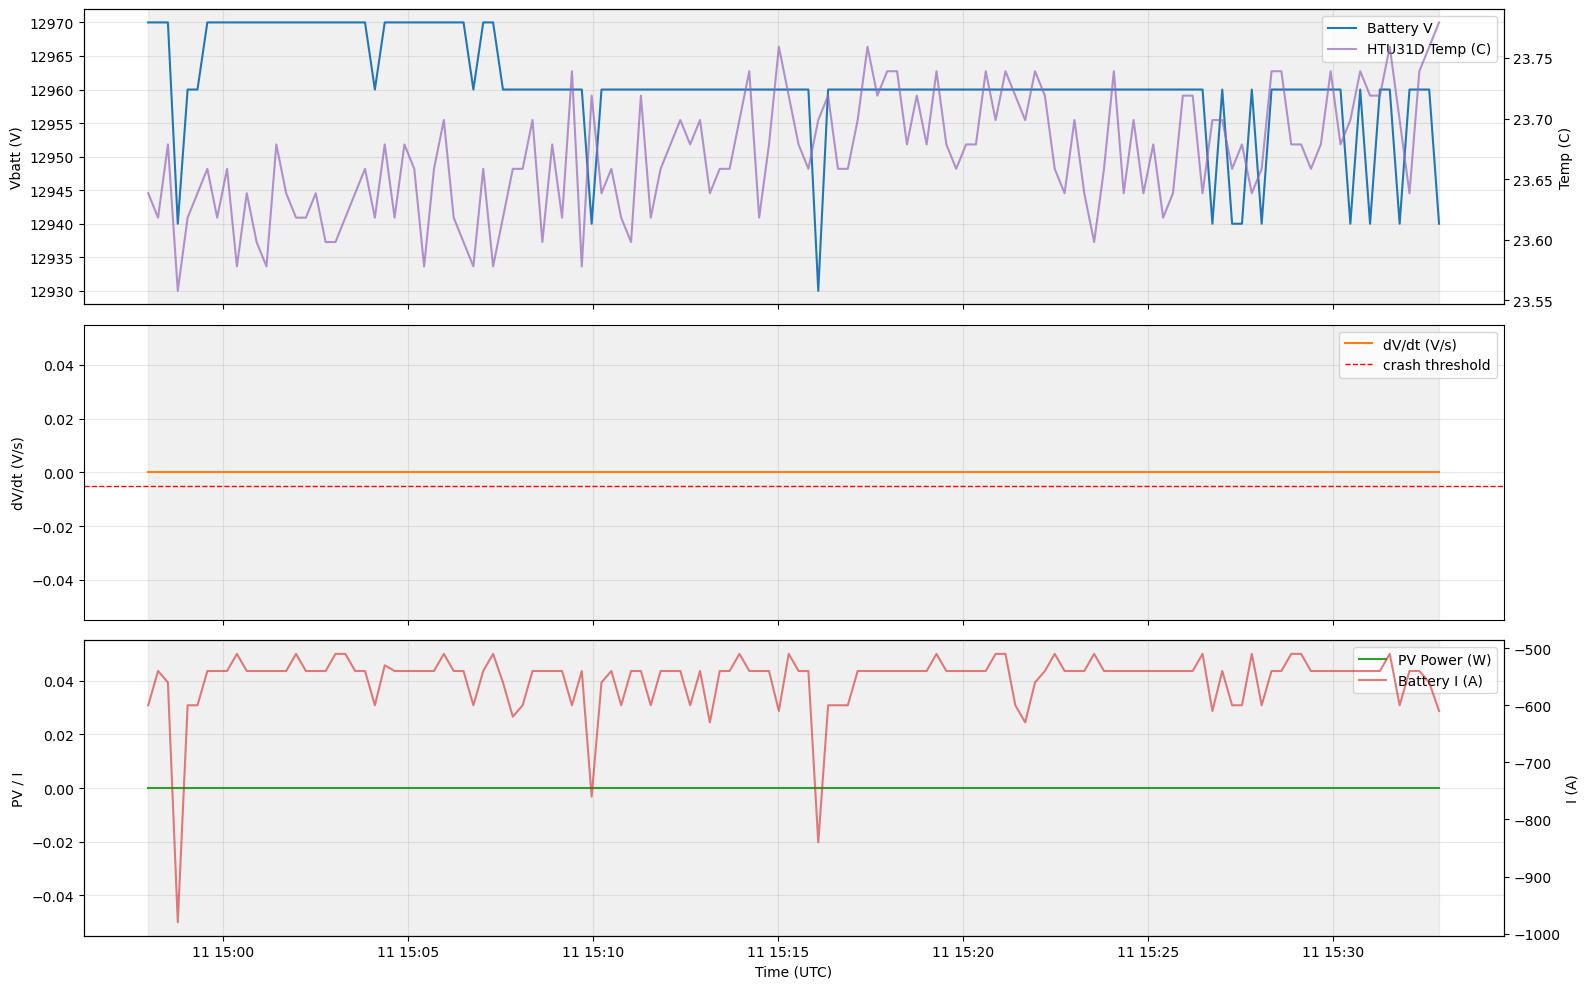

In [12]:
# Diagnostic plots with day/night shading and crash windows
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

vb = pd.to_numeric(df[v_batt], errors="coerce")
dvdt = df.get("derived_dVdt_V_per_s")
is_day = df["derived_is_daylight"].astype(bool)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# 1) Battery voltage
axes[0].plot(vb.index, vb, label="Battery V", color="tab:blue")
axes[0].set_ylabel("Vbatt (V)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Overlay HTU31D temperature on a secondary y-axis if available
temp_col = None
for c in df.columns:
    lc = str(c).lower()
    if "htu31d" in lc and "temp" in lc:
        temp_col = c
        break
if temp_col is not None:
    temp = pd.to_numeric(df[temp_col], errors="coerce")
    if temp.notna().any():
        ax0b = axes[0].twinx()
        ax0b.plot(temp.index, temp, label="HTU31D Temp (C)", color="tab:purple", alpha=0.7)
        ax0b.set_ylabel("Temp (C)")
        # Combine legends on the left axis
        l0, la0 = axes[0].get_legend_handles_labels()
        l0b, la0b = ax0b.get_legend_handles_labels()
        axes[0].legend(l0 + l0b, la0 + la0b, loc="upper right")

# 2) dV/dt
if dvdt is not None:
    axes[1].plot(dvdt.index, dvdt, label="dV/dt (V/s)", color="tab:orange")
    axes[1].axhline(-0.005, color="red", ls="--", lw=1, label="crash threshold")
    axes[1].set_ylabel("dV/dt (V/s)")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)

# 3) PV and current/power
if p_pv is not None:
    pvP = pd.to_numeric(df[p_pv], errors="coerce")
    axes[2].plot(pvP.index, pvP, label="PV Power (W)", color="tab:green")
elif v_pv is not None:
    vpv = pd.to_numeric(df[v_pv], errors="coerce")
    axes[2].plot(vpv.index, vpv, label="PV Voltage (V)", color="tab:green")
else:
    axes[2].text(0.01, 0.8, "No PV metrics found", transform=axes[2].transAxes)

if i_batt is not None:
    ib = pd.to_numeric(df[i_batt], errors="coerce")
    ax2 = axes[2].twinx()
    ax2.plot(ib.index, ib, label="Battery I (A)", color="tab:red", alpha=0.6)
    ax2.set_ylabel("I (A)")
    # Combine legends
    lines, labels = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[2].legend(lines + lines2, labels + labels2, loc="upper right")
else:
    axes[2].legend(loc="upper right")
axes[2].set_ylabel("PV / I")
axes[2].grid(True, alpha=0.3)

# Shade night periods
# Find contiguous night spans for shading
night = ~is_day.fillna(False)
in_night = False
n_start = None
for t, is_n in night.items():
    if is_n and not in_night:
        in_night = True
        n_start = t
    elif not is_n and in_night:
        for ax in axes:
            ax.axvspan(n_start, t, color="black", alpha=0.06)
        in_night = False
if in_night and n_start is not None:
    for ax in axes:
        ax.axvspan(n_start, df.index[-1], color="black", alpha=0.06)

# Shade crash windows, if any
for s, e in crash_ranges:
    for ax in axes:
        ax.axvspan(s, e, color="red", alpha=0.12)

axes[-1].set_xlabel("Time (UTC)")
plt.tight_layout()
plt.show()

In [13]:
# Summary interpretation
import pandas as pd
import numpy as np

summary = {}
# Crash timing vs sunlight
if len(crash_ranges) > 0:
    first_s, first_e = crash_ranges[0]
    in_day = df.loc[first_s:first_e, "derived_is_daylight"].mean()
    summary["crash_window"] = (str(first_s), str(first_e))
    summary["crash_in_daylight_fraction"] = float(in_day) if not np.isnan(in_day) else None
else:
    summary["crash_window"] = None
    summary["crash_in_daylight_fraction"] = None

# PV around crash
if len(crash_ranges) > 0:
    win_s, win_e = crash_ranges[0]
    if p_pv is not None:
        pvP = pd.to_numeric(df[p_pv], errors="coerce")
        pv_avg = pvP.loc[win_s:win_e].mean()
        pv_peak = pvP.loc[win_s:win_e].max()
        summary["pv_avg_W_in_crash"] = None if np.isnan(pv_avg) else float(pv_avg)
        summary["pv_peak_W_in_crash"] = None if np.isnan(pv_peak) else float(pv_peak)
    elif v_pv is not None:
        vpv = pd.to_numeric(df[v_pv], errors="coerce")
        summary["pv_voltage_mean_in_crash"] = float(vpv.loc[win_s:win_e].mean())
else:
    summary["pv_avg_W_in_crash"] = None

# Daily PV sufficiency proxy
day_ok = None
if "pv_energy_Wh" in df_day.columns and df_day["pv_energy_Wh"].notna().any():
    # Compare net charge vs discharge if available
    if {"battery_charge_Ah", "battery_discharge_Ah"}.issubset(df_day.columns):
        # crude conversion using average Vbatt of each day to estimate Wh from Ah delta
        vb_daily = pd.to_numeric(df[v_batt], errors="coerce").resample('1D').mean()
        net_Ah = (df_day["battery_charge_Ah"] - df_day["battery_discharge_Ah"]).fillna(0)
        est_Wh = (net_Ah * vb_daily).fillna(0)
        # Compare PV energy vs estimated consumption magnitude
        cmp = (df_day["pv_energy_Wh"] - est_Wh).dropna()
        day_ok = (cmp > 0).mean() if not cmp.empty else None
    summary["days_pv_sufficient_fraction"] = None if day_ok is None else float(day_ok)

print("Analysis summary:")
for k, v in summary.items():
    print(f" - {k}: {v}")

if summary.get("crash_in_daylight_fraction") is not None:
    if summary["crash_in_daylight_fraction"] < 0.2:
        print("Crash appears to have occurred mostly at night or with negligible PV.")
    elif summary["crash_in_daylight_fraction"] > 0.8:
        print("Crash occurred in daylight—PV may have been insufficient or loads too high.")
    else:
        print("Crash spanned both day and night—consider charge/discharge balance and loads.")

Analysis summary:
 - crash_window: None
 - crash_in_daylight_fraction: None
 - pv_avg_W_in_crash: None
 - days_pv_sufficient_fraction: 1.0


In [19]:
!head -50 /var/log/rpi-health.log

{
  "ts": "2025-08-11T17:39:00Z",
  "vcgencmd": {
    "throttled": "0x0",
    "temp_c": "55.4"
  },
  "loadavg": "0.08,0.06,0.08",
  "mem": {"total_kb": 8256896, "avail_kb": 4518016},
  "top": [{"pid":1990,"cpu":4.6,"mem":14.2,"comm":"node"},{"pid":2620,"cpu":2.6,"mem":18.6,"comm":"node"},{"pid":2699,"cpu":0.3,"mem":3.2,"comm":"python"},{"pid":1905,"cpu":0.1,"mem":1.4,"comm":"node"},{"pid":99,"cpu":0.0,"mem":0.0,"comm":"irq/38-aerdrv"}],
  "kmsg_recent": ""
}

{
  "ts": "2025-08-11T17:39:00Z",
  "vcgencmd": {
    "throttled": "0x0",
    "temp_c": "55.4"
  },
  "loadavg": "0.08,0.06,0.08",
  "mem": {"total_kb": 8256896, "avail_kb": 4518016},
  "top": [{"pid":1990,"cpu":4.6,"mem":14.2,"comm":"node"},{"pid":2620,"cpu":2.6,"mem":18.6,"comm":"node"},{"pid":2699,"cpu":0.3,"mem":3.2,"comm":"python"},{"pid":1905,"cpu":0.1,"mem":1.4,"comm":"node"},{"pid":99,"cpu":0.0,"mem":0.0,"comm":"irq/38-aerdrv"}],
  "kmsg_recent": ""
}
{"ts":"2025-08-11T17:40:06Z","boot_id":"905d7454-f719-4058-a7dd-654e882

In [ ]:
# Parse RPi health log (/var/log/rpi-health.log) and correlate with Vbatt
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

health_path = "/var/log/rpi-health.log"
recs = []
try:
    # Counters for diagnostics
    total_lines = 0
    parsed_ok = 0
    skipped_json_error = 0
    skipped_bad_ts = 0
    skipped_outside_json = 0
    unfinished_objects = 0

    # Buffer state for multi-line JSON objects
    buf = []
    depth = 0
    in_str = False
    escape = False

    def feed_chunk(chunk, state):
        depth, in_str, escape = state
        for ch in chunk:
            if escape:
                escape = False
                continue
            if ch == "\\":
                if in_str:
                    escape = True
                continue
            if ch == '"':
                in_str = not in_str
                continue
            if not in_str:
                if ch == '{':
                    depth += 1
                elif ch == '}':
                    depth -= 1
        return depth, in_str, escape

    with open(health_path, 'r', encoding='utf-8', errors='ignore') as fh:
        for ln in fh:
            total_lines += 1
            line = ln.rstrip('\n')
            # If not currently buffering an object, look for a '{' to start
            if depth == 0 and not buf:
                # fast-path: skip lines with no opening brace
                if '{' not in line:
                    skipped_outside_json += 1
                    continue
                # start buffering from the first '{' to handle any prefix noise
                start = line.find('{')
                fragment = line[start:]
                buf = [fragment]
                depth, in_str, escape = feed_chunk(fragment, (depth, in_str, escape))
            else:
                # Continue buffering current object
                buf.append(line)
                depth, in_str, escape = feed_chunk(line, (depth, in_str, escape))

            # If balanced (depth==0) and we have a buffer, attempt to parse the full object
            if depth == 0 and buf:
                blob = "\n".join(buf).strip()
                buf = []
                # Some logs may have trailing characters after a JSON object; trim to last closing brace
                try:
                    last_brace = blob.rfind('}')
                    if last_brace != -1:
                        blob = blob[:last_brace+1]
                    obj = json.loads(blob)
                except Exception as e:
                    head = blob[:120].replace('\n',' ')
                    print(f"[health-parse] json error (ends at line {total_lines}): {e}; head={head!r}")
                    skipped_json_error += 1
                    continue

                ts = pd.to_datetime(obj.get('ts'), utc=True, errors='coerce')
                if pd.isna(ts):
                    print(f"[health-parse] bad timestamp (ends at line {total_lines}); keys={list(obj.keys())}")
                    skipped_bad_ts += 1
                    continue

                rec = {
                    'timestamp': ts,
                    'throttled': obj.get('vcgencmd', {}).get('throttled'),
                    'temp_c': pd.to_numeric(obj.get('vcgencmd', {}).get('temp_c'), errors='coerce'),
                    'load1': np.nan, 'load5': np.nan, 'load15': np.nan,
                    'mem_avail_kb': pd.to_numeric(obj.get('mem', {}).get('avail_kb'), errors='coerce'),
                    # capture recent kernel messages collected by the logger (journald-based) for event correlation
                    'kmsg_recent': obj.get('kmsg_recent') or obj.get('dmesg_recent') or ''
                }
                # loadavg may be a string like "1.23,0.89,0.77" or an array [1.23, 0.89, 0.77]
                la_val = obj.get('loadavg', '')
                if isinstance(la_val, (list, tuple)) and len(la_val) >= 3:
                    rec['load1'] = pd.to_numeric(la_val[0], errors='coerce')
                    rec['load5'] = pd.to_numeric(la_val[1], errors='coerce')
                    rec['load15'] = pd.to_numeric(la_val[2], errors='coerce')
                else:
                    la = str(la_val) if la_val is not None else ''
                    parts = la.split(',') if la else []
                    if len(parts) >= 3:
                        rec['load1'] = pd.to_numeric(parts[0], errors='coerce')
                        rec['load5'] = pd.to_numeric(parts[1], errors='coerce')
                        rec['load15'] = pd.to_numeric(parts[2], errors='coerce')
                recs.append(rec)
                parsed_ok += 1

    # If file ended with an unfinished buffered object, account for it
    if buf and depth != 0:
        unfinished_objects += 1

    print(f"[health-parse] lines={total_lines}, parsed_ok={parsed_ok}, skipped_outside_json={skipped_outside_json}, skipped_json_error={skipped_json_error}, skipped_bad_ts={skipped_bad_ts}, unfinished_objects={unfinished_objects}")
    dfh = pd.DataFrame.from_records(recs)
except FileNotFoundError:
    print('Health log not found. Run sudo bash scripts/enable_rpi_logging.sh to install the logger.')
dfh.shape

[health-parse] json error (line 1): Expecting property name enclosed in double quotes: line 1 column 2 (char 1); head='{'
[health-parse] skip non-json (line 2): "ts": "2025-08-11T17:39:00Z",
[health-parse] skip non-json (line 3): "vcgencmd": {
[health-parse] skip non-json (line 4): "throttled": "0x0",
[health-parse] skip non-json (line 5): "temp_c": "55.4"
[health-parse] skip non-json (line 6): },
[health-parse] skip non-json (line 7): "loadavg": "0.08,0.06,0.08",
[health-parse] skip non-json (line 8): "mem": {"total_kb": 8256896, "avail_kb": 4518016},
[health-parse] skip non-json (line 9): "top": [{"pid":1990,"cpu":4.6,"mem":14.2,"comm":"node"},{"pid":2620,"cpu":2.6,"mem":18.6,"comm":"node"},{"pid":2699,"cpu
[health-parse] skip non-json (line 10): "kmsg_recent": ""
[health-parse] skip non-json (line 11): }
[health-parse] skip non-json (line 12): 
[health-parse] json error (line 13): Expecting property name enclosed in double quotes: line 1 column 2 (char 1); head='{'
[health-parse] sk

(5, 7)

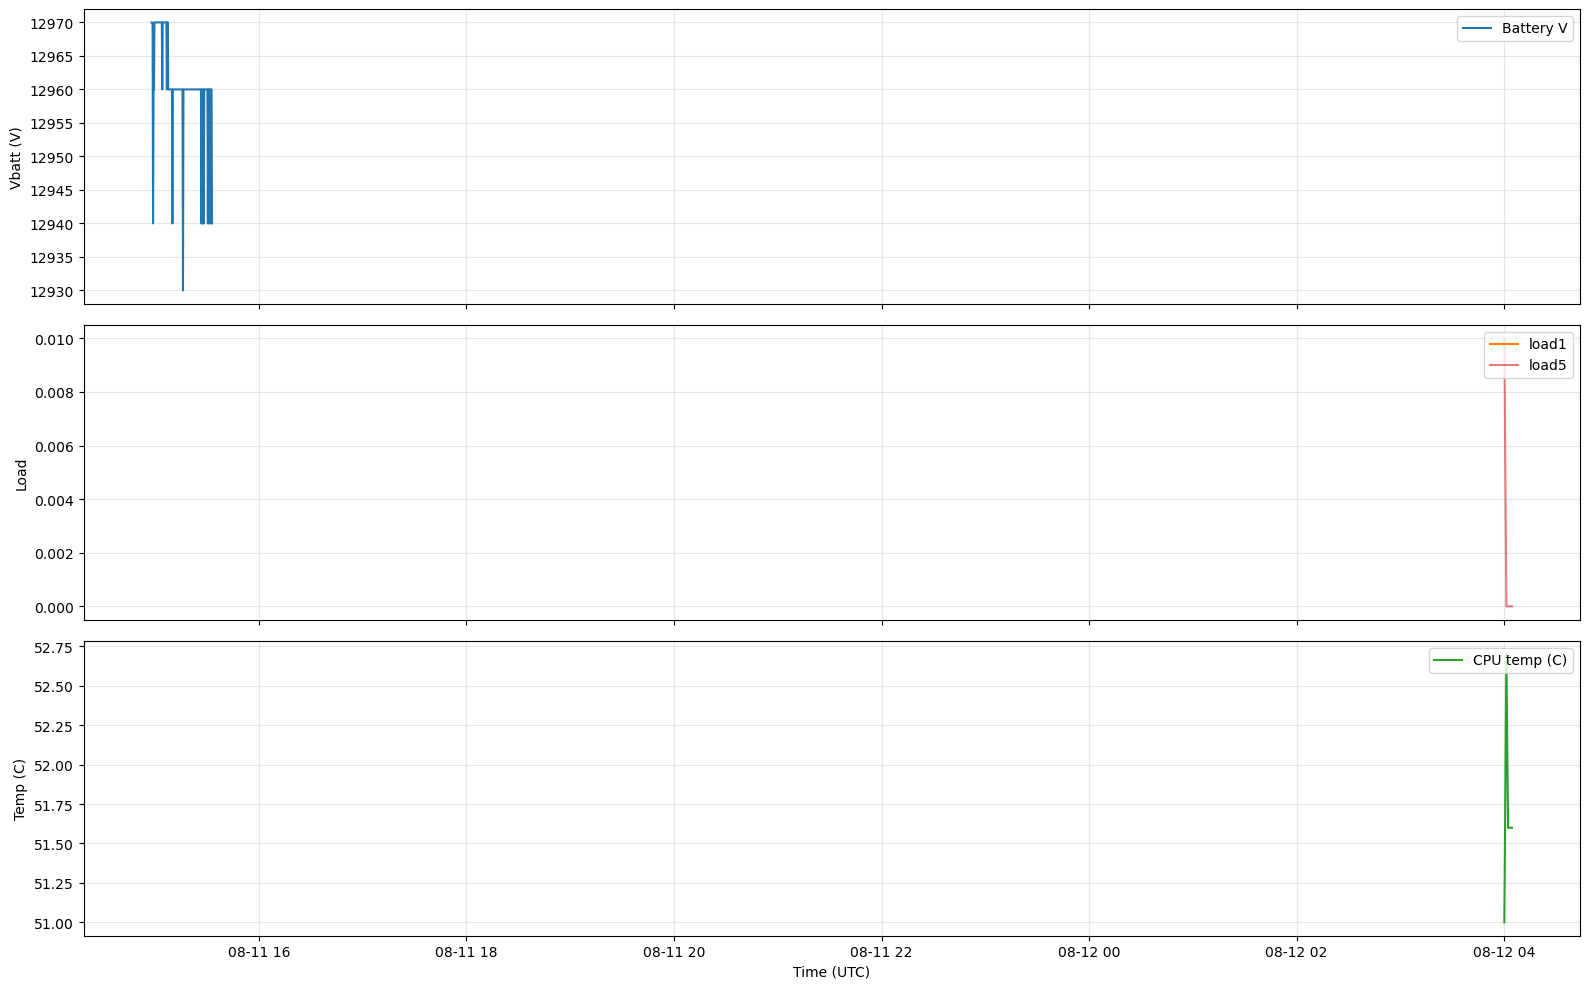

In [16]:
if not dfh.empty:
    dfh = dfh.set_index('timestamp').sort_index()
    # plot against Vbatt
    vb = pd.to_numeric(df[v_batt], errors='coerce')
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    axes[0].plot(vb.index, vb, color='tab:blue', label='Battery V')
    axes[0].set_ylabel('Vbatt (V)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(dfh.index, dfh['load1'], label='load1', color='tab:orange')
    axes[1].plot(dfh.index, dfh['load5'], label='load5', color='tab:red', alpha=0.6)
    axes[1].set_ylabel('Load')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(dfh.index, dfh['temp_c'], label='CPU temp (C)', color='tab:green')
    axes[2].set_ylabel('Temp (C)')
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
    for s, e in crash_ranges:
        for ax in axes:
            ax.axvspan(s, e, color='red', alpha=0.12)
    axes[-1].set_xlabel('Time (UTC)')
    plt.tight_layout()
    plt.show()
else:
    print('No records in /var/log/rpi-health.log yet. The systemd timer runs every minute after you install it.')


In [ ]:
# Examine coincident kernel events and throttling near crash windows using rpi-health-logger records
import re
import pandas as pd
import numpy as np

if 'dfh' not in globals() or dfh is None or dfh.empty:
    print("Health log DataFrame (dfh) is empty or missing; run the previous cell after logs accumulate.")
elif 'crash_ranges' not in globals() or len(crash_ranges) == 0:
    print("No crash windows detected; run the detection cells first.")
else:
    # Build a time window around each crash and scan kmsg_recent + throttled
    out_rows = []
    patterns = {
        'undervolt': re.compile(r'under-?volt', re.I),
        'oom': re.compile(r'Out of memory|OOM killer', re.I),
        'usb': re.compile(r'usb|xhci|uhci|hub', re.I),
        'net': re.compile(r'link is (up|down)|eth|wlan|network|DHCP', re.I),
        'disk': re.compile(r'EXT4|mmc|sd[a-z]|i/o error|fsck', re.I),
        'thermal': re.compile(r'thermal|overheat|temp', re.I),
        'power': re.compile(r'voltage|power|throttl', re.I),
        'python': re.compile(r'python', re.I),
    }
    # 10-minute window around each crash
    pad = pd.Timedelta(minutes=10)
    for (s, e) in crash_ranges:
        win_s, win_e = s - pad, e + pad
        slice_h = dfh.loc[(dfh.index >= win_s) & (dfh.index <= win_e)].copy()
        if slice_h.empty:
            continue
        # count pattern hits
        text = (slice_h['kmsg_recent'].fillna('').str.cat(sep='\n'))
        counts = {name: (pat.findall(text) or []) for name, pat in patterns.items()}
        counts = {name: len(v) for name, v in counts.items()}
        # summarize throttled flags observed
        thr = slice_h['throttled'].dropna().astype(str).unique().tolist()
        out_rows.append({
            'crash_start': str(s), 'crash_end': str(e),
            'throttled_values_seen': ','.join(thr) if thr else '',
            **{f'count_{k}': v for k, v in counts.items()}
        })
    summary_df = pd.DataFrame(out_rows)
    if summary_df.empty:
        print("No health/kmsg events found near crash windows.")
    else:
        # Show top categories by total hits
        totals = summary_df[[c for c in summary_df.columns if c.startswith('count_')]].sum().sort_values(ascending=False)
        print("Coincident kernel-event counts near crash windows (10-min padding):")
        print(totals.to_string())
        print("\nPer-window summary:")
        display(summary_df)